In [1]:
import torch
import torch.nn.functional as F
from torchvision.transforms.functional import pil_to_tensor
from transformers import AutoTokenizer, Siglip2TextModel, AutoConfig
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path
PROJECTS_ROOT = Path("/workspace/projects")
if str(PROJECTS_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECTS_ROOT))

try:
    from nvidia_radio.hubconf import radio_model
    from nvidia_radio.radio.pamr import PAMR
except ImportError:
    from projects.nvidia_radio.hubconf import radio_model
    from projects.nvidia_radio.radio.pamr import PAMR

In [2]:
# 1. Setup device and load the C-RADIOv4-H model with the SigLIP2 adapter
device = "cuda" if torch.cuda.is_available() else "cpu"
# device="cpu"
print("Device:",device)

#model_version="radio_v2.5-g" # for RADIOv2.5-g model (ViT-H/14)
# model_version="radio_v2.5-h" # for RADIOv2.5-H model (ViT-H/16)
# model_version="radio_v2.5-l" # for RADIOv2.5-L model (ViT-L/16)
# model_version="radio_v2.5-b" # for RADIOv2.5-B model (ViT-B/16)
model_version="c-radio_v3-b" # for C_RADIOv3-B model (ViT-B/16)
# model_version="e-radio_v2" # for E-RADIO
adaptor_version="siglip2" # ["clip", siglip", "siglip2"] for v2 and v3 models

#### v4 Models- Currently not working, need to edit radio_model loading code ####
# model_version = "c-radio_v4-so400m" # for C-RADIOv4-SO400M model (ViT-B/16)
# model_version = "c-radio_v4-h" # for C-RADIOv4-H model (ViT-H/16)
# adaptor_version = "siglip2-g" # ['siglip2-g', 'dino_v3_7b', 'sam3'] for v4 models
print(f"Loading {model_version}...")
 
print(f"Loading {model_version} with {adaptor_version} adapter...")
model, chk = radio_model(
    version=model_version,
    progress=True,
    skip_validation=True,
    adaptor_names=adaptor_version,
    return_checkpoint=True, 
    use_naclip=True, 
    naclip_strategy="kkonly", #"kkonly",
    naclip_gaussian_std=5.0,
    fixed_patch_dim=(40,40), #(45,80),
    gaussian_device='cuda',
    use_summary_for_spatial=True
)
model.cuda().eval()

## BAD MODEL - don't know why?
# model = torch.hub.load(
#     "NVlabs/RADIO",
#     "radio_model",
#     version=model_version,
#     adaptor_names=[adaptor_version],
#     progress=True,
#     skip_validation=True,
#     use_naclip=True,
#     naclip_strategy="kkonly",
#     naclip_gaussian_std=5.0,
#     fixed_patch_dim=(40,40),
#     gaussian_device=device,
#     use_summary_for_spatial=True,
# ).to(device).eval()


print(model.adaptors)
print("Adapter names:", list(model.adaptors.keys()))

Device: cuda
Loading c-radio_v3-b...
Loading c-radio_v3-b with siglip2 adapter...
Downloading: "https://huggingface.co/nvidia/C-RADIOv3-B/resolve/main/c-radio_v3-b_half.pth.tar?download=true" to /root/ckpts/c-radio_v3-b_half.pth.tar


100%|██████████| 521M/521M [00:10<00:00, 52.8MB/s] 


[INFO] Loading SigLIP2 model and processor for version: google/siglip2-so400m-patch16-naflex
[INFO] Using checkpoint path: /root/.cache/huggingface/hub


config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


...

tokenizer_config.json:   0%|          | 0.00/40.2k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 34.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

ModuleDict(
  (siglip2): SigLIP2Adaptor(
    (head_mlp): MLP2(
      (pre_norm): Identity()
      (fc1): Linear(in_features=768, out_features=1520, bias=True)
      (blocks): ModuleList(
        (0-1): 2 x Sequential(
          (0): LayerNorm((1520,), eps=1e-05, elementwise_affine=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1520, out_features=1520, bias=True)
        )
      )
      (final): Sequential(
        (0): LayerNorm((1520,), eps=1e-05, elementwise_affine=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=1520, out_features=1152, bias=True)
      )
    )
    (feat_mlp): MLP2(
      (pre_norm): Identity()
      (fc1): Linear(in_features=768, out_features=1520, bias=True)
      (blocks): ModuleList(
        (0-1): 2 x Sequential(
          (0): LayerNorm((1520,), eps=1e-05, elementwise_affine=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1520, out_features=1520, bias=True)
        )
  

In [3]:
# 3. Load sample image and prepare text prompts
img_path = '/workspace/projects/Grounded-Segment-Anything/assets/inpaint_demo.jpg'
image = Image.open(img_path).convert("RGB")
image_tensor = pil_to_tensor(image).to(dtype=torch.float32, device=device)
image_tensor.div_(255.0)  # RADIO expects the input values to be between 0 and 1
image_tensor = image_tensor.unsqueeze(0) # Add a batch dimension

#### Example 1 ####
# Regular Usage
###################
nearest_res = model.get_nearest_supported_resolution(*image_tensor.shape[-2:])
image_tensor = F.interpolate(image_tensor, nearest_res, mode='bilinear', align_corners=False)
orig_w, orig_h = image.size

In [4]:
vis_output = model(image_tensor)
backbone_summary, backbone_features = vis_output["backbone"]
sig2_summary, spatial_vision_features = vis_output["siglip2"]
print("sig2_summary.shape",sig2_summary.shape,"spatial_vision_features.shape",spatial_vision_features.shape)

sig2_summary.shape torch.Size([1, 1152]) spatial_vision_features.shape torch.Size([1, 1024, 1152])


In [5]:
# text_query = ['a bench']
text_query = ['a fluffy dog', 'a bench']
# The 'siglip2-g' and 'clip' adaptors (when available) are special because they also support text tokenization and encoding
sig2_adaptor = model.adaptors['siglip2']
text_input = sig2_adaptor.tokenizer(text_query).to(device)
text_tokens = sig2_adaptor.encode_text(text_input, normalize=True)
print("text_tokens.shape:",text_tokens.shape)

sim = F.cosine_similarity(sig2_summary, text_tokens)
print(sim)

text_tokens.shape: torch.Size([2, 1152])
tensor([0.0544, 0.0693], device='cuda:0', grad_fn=<SumBackward1>)


In [6]:
spatial_feats = spatial_vision_features.squeeze() # Remove batch dimension, shape: [Channels, Height, Width]
spatial_feats = spatial_feats / spatial_feats.norm(dim=0, keepdim=True) # Normalize spatial features
print("spatial_feats.shape",spatial_feats.shape)

spatial_feats.shape torch.Size([1024, 1152])


In [7]:
text_tokens.shape

torch.Size([2, 1152])

In [8]:
# ---------------------------------------------------------------------------
# 5. Calculate Cosine Similarity Heatmap
# ---------------------------------------------------------------------------
# text_features: (1, D), spatial_vision_features: (T, D) -> similarity: (T,)
similarity = torch.matmul(text_tokens, spatial_feats.T).squeeze(0)
print("Similarity.shape:",similarity.shape)

Similarity.shape: torch.Size([2, 1024])


In [9]:
task_idx = 0
# ---------------------------------------------------------------------------
# 6. Reshape the 1D similarity array back to the 2D spatial grid
# ---------------------------------------------------------------------------
heatmap = similarity[task_idx,:].view(32, 32).detach().cpu().numpy()
 
# Upscale the patch matrix to overlay original image dimensions
heatmap_resized = np.array(Image.fromarray(heatmap).resize((orig_w, orig_h), resample=Image.BILINEAR))
 
# Normalize heatmap values cleanly between 0 and 1
heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min() + 1e-8)

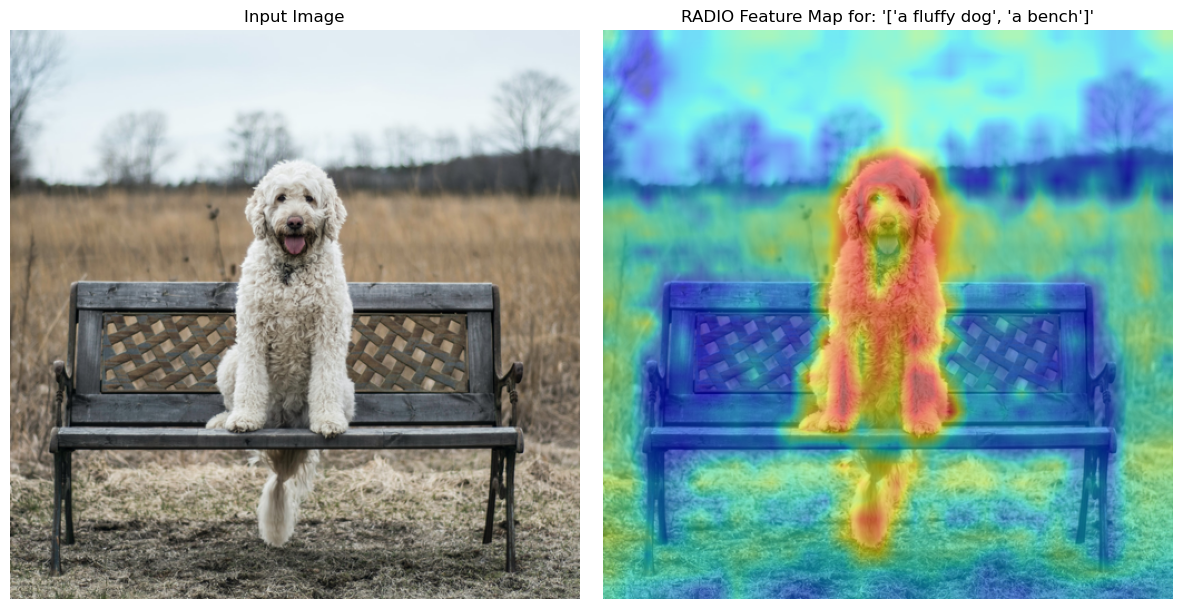

In [10]:
# ---------------------------------------------------------------------------
# 7. Render the Heatmap Visual
# ---------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
 
# Subplot 1: Input Image
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
 
# Subplot 2: SigLIP2 Semantic Overlay on RADIO Features
plt.subplot(1, 2, 2)
plt.imshow(image)
plt.imshow(heatmap_resized, cmap="jet", alpha=0.5)  # Jet color palette for heat scale
plt.title(f"RADIO Feature Map for: '{text_query}'")
plt.axis("off")
 
plt.tight_layout()
plt.show()

In [11]:
print("Max:",heatmap_resized.max(), "Min:", heatmap_resized.min())

Max: 0.99999994 Min: 0.0


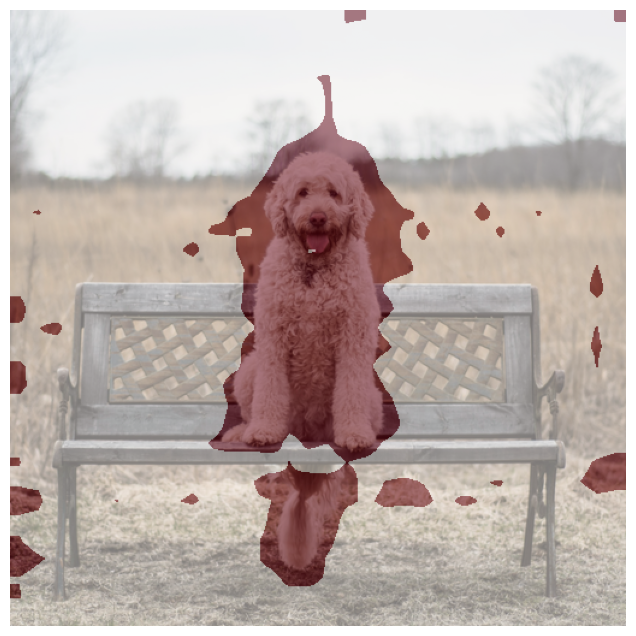

In [12]:
THRESHOLD = 0.5

# Create binary mask
mask = heatmap_resized > THRESHOLD

# Plot original image
plt.figure(figsize=(10, 8))
plt.imshow(image)

# Overlay mask
plt.imshow(mask, alpha=0.5, cmap="Reds")

plt.axis("off")
plt.show()